In [1]:
import gc, os, json, pickle, warnings
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import psutil
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)
from tqdm import tqdm
tqdm.pandas()
warnings.filterwarnings('ignore')

DATA_DIR = '/home/arshad/Network-project/data/'

# Load risk scored dataset
df = pd.read_csv(DATA_DIR + 'final_risk_scored.csv', low_memory=False)
df['MITRE_Tactic']    = df['MITRE_Tactic'].fillna('None')
df['MITRE_Technique'] = df['MITRE_Technique'].fillna('None')

# Load saved assets
with open(DATA_DIR + 'mitre_techniques.pkl', 'rb') as f:
    techniques = pickle.load(f)
with open(DATA_DIR + 'tactic_classifier.pkl', 'rb') as f:
    clf_data   = pickle.load(f)

clf          = clf_data['model']
le           = clf_data['encoder']
feature_cols = clf_data['features']

index                = faiss.read_index(DATA_DIR + 'mitre_faiss.index')
technique_embeddings = np.load(DATA_DIR + 'mitre_embeddings.npy')

print("⏳ Loading embedding model...")
emb_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"✅ All assets loaded!")
print(f"✅ Dataset: {df.shape[0]:,} rows")
print(f"💾 RAM: {psutil.virtual_memory().available/1024**3:.1f} GB")

⏳ Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ All assets loaded!
✅ Dataset: 62,143 rows
💾 RAM: 10.7 GB


In [2]:
def get_parent_id(tid):
    return tid.split('.')[0] if isinstance(tid, str) and '.' in tid else tid

tactic_id_to_name = {
    'TA0001':'initial-access',    'TA0002':'execution',
    'TA0003':'persistence',       'TA0004':'privilege-escalation',
    'TA0005':'defense-evasion',   'TA0006':'credential-access',
    'TA0007':'discovery',         'TA0008':'lateral-movement',
    'TA0009':'collection',        'TA0010':'exfiltration',
    'TA0011':'command-and-control','TA0040':'impact',
    'TA0042':'resource-development','TA0043':'reconnaissance',
    'None':'None',
}

tactic_map = {
    'BENIGN':                    'benign',
    'DoS Hulk':                  'impact',
    'DoS GoldenEye':             'impact',
    'DoS slowloris':             'impact',
    'DoS Slowhttptest':          'impact',
    'DDoS':                      'impact',
    'PortScan':                  'discovery',
    'FTP-Patator':               'credential-access',
    'SSH-Patator':               'credential-access',
    'Bot':                       'command-and-control',
    'Web Attack - Brute Force':  'initial-access',
    'Web Attack - XSS':          'initial-access',
    'Web Attack - SQL Injection':'initial-access',
    'Heartbleed':                'initial-access',
    'Infiltration':              'lateral-movement',
}

attack_df = df[df['Label'] != 'BENIGN'].copy()
attack_df['true_parent']  = attack_df['MITRE_Technique'].apply(get_parent_id)
attack_df['pred1_parent'] = attack_df['pred_technique_1'].apply(get_parent_id)
attack_df['pred2_parent'] = attack_df['pred_technique_2'].apply(get_parent_id)
attack_df['pred3_parent'] = attack_df['pred_technique_3'].apply(get_parent_id)
attack_df['true_tactic']  = attack_df['Label'].map(tactic_map)

print("✅ Helper functions defined!")
print(f"✅ Attack samples: {len(attack_df):,}")

✅ Helper functions defined!
✅ Attack samples: 57,143


In [3]:
print("📊 PART 1: OUR HYBRID SYSTEM EVALUATION")
print("=" * 60)

# Tactic accuracy
tactic_true = attack_df['true_tactic']
tactic_pred = attack_df['ml_pred_tactic']
tactic_acc  = accuracy_score(tactic_true, tactic_pred)

# MITRE technique accuracy
top1 = (attack_df['true_parent'] == attack_df['pred1_parent']).mean()
top3 = attack_df.apply(
    lambda r: r['true_parent'] in [
        r['pred1_parent'], r['pred2_parent'], r['pred3_parent']
    ], axis=1
).mean()

print(f"\n🎯 Tactic Classification Accuracy:  {tactic_acc:.2%}")
print(f"🎯 MITRE Technique Top-1 Accuracy:  {top1:.2%}")
print(f"🎯 MITRE Technique Top-3 Accuracy:  {top3:.2%}")

# Per attack type metrics
print(f"\n📊 Per Attack Type — Tactic Classification:")
print("-" * 60)
print(classification_report(
    tactic_true, tactic_pred,
    digits=3, zero_division=0
))

# Per attack MITRE accuracy
print(f"\n📊 Per Attack Type — MITRE Top-3 Accuracy:")
print("-" * 60)
print(f"{'Attack Type':<35} {'Top-1':>6}  {'Top-3':>6}  {'Count':>7}")
print("-" * 60)
for label in sorted(attack_df['Label'].unique()):
    sub = attack_df[attack_df['Label'] == label]
    t1  = (sub['true_parent'] == sub['pred1_parent']).mean()
    t3  = sub.apply(lambda r: r['true_parent'] in [
              r['pred1_parent'], r['pred2_parent'],
              r['pred3_parent']], axis=1).mean()
    status = "✅" if t3 >= 0.5 else "⚠️ "
    print(f"  {status} {label:<33} {t1:>5.0%}   {t3:>5.0%}   {len(sub):>6,}")

📊 PART 1: OUR HYBRID SYSTEM EVALUATION

🎯 Tactic Classification Accuracy:  99.81%
🎯 MITRE Technique Top-1 Accuracy:  66.34%
🎯 MITRE Technique Top-3 Accuracy:  83.45%

📊 Per Attack Type — Tactic Classification:
------------------------------------------------------------
                     precision    recall  f1-score   support

             benign      0.000     0.000     0.000         0
command-and-control      0.999     0.998     0.999      1953
  credential-access      1.000     1.000     1.000      8000
          discovery      1.000     0.998     0.999     10000
             impact      1.000     0.998     0.999     35000
     initial-access      0.988     0.999     0.993      2154
   lateral-movement      1.000     0.944     0.971        36

           accuracy                          0.998     57143
          macro avg      0.855     0.848     0.852     57143
       weighted avg      0.999     0.998     0.999     57143


📊 Per Attack Type — MITRE Top-3 Accuracy:
------------

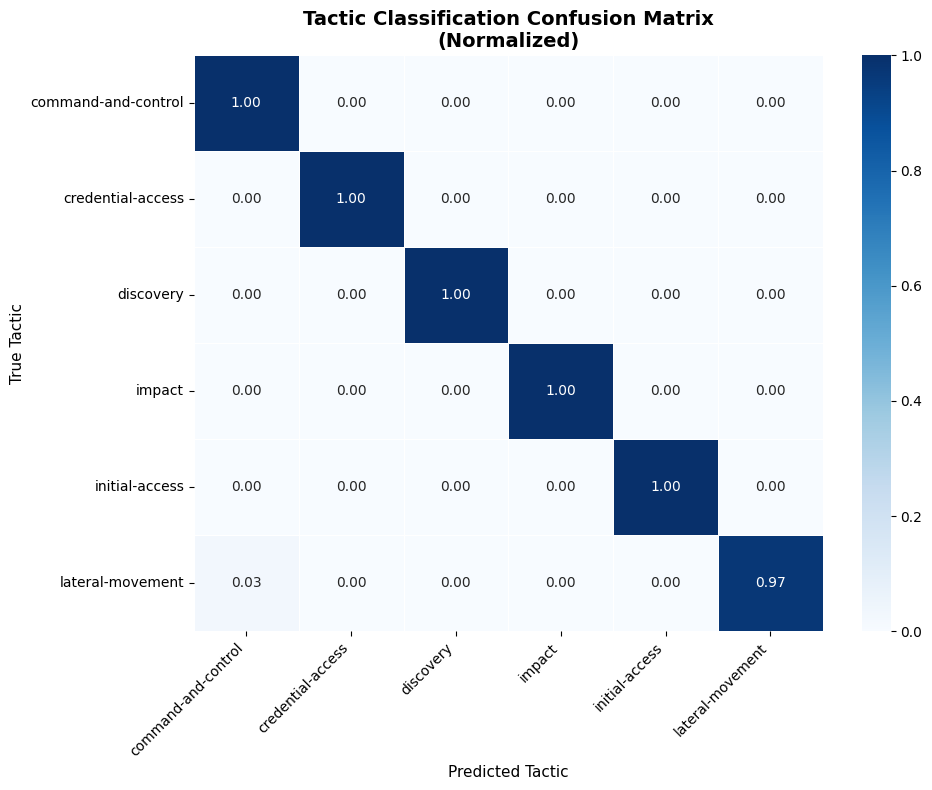

✅ Confusion matrix saved!


In [4]:
# Tactic confusion matrix
labels_order = sorted(attack_df['true_tactic'].unique())
cm = confusion_matrix(
    attack_df['true_tactic'],
    attack_df['ml_pred_tactic'],
    labels=labels_order
)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_pct, annot=True, fmt='.2f',
    xticklabels=labels_order,
    yticklabels=labels_order,
    cmap='Blues', ax=ax,
    linewidths=0.5, vmin=0, vmax=1
)
ax.set_title('Tactic Classification Confusion Matrix\n(Normalized)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('True Tactic', fontsize=11)
ax.set_xlabel('Predicted Tactic', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/home/arshad/Network-project/reports/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

In [5]:
print("📊 BASELINE 1: Rule-Based Keyword Matching")
print("=" * 60)
print("(Simulates traditional SOC tools — port + flag rules only)")
print()

def rule_based_tactic(row):
    """
    Simple rule-based classifier — represents traditional SOC.
    Uses only port number and basic traffic stats.
    No ML, no embeddings, no semantic understanding.
    """
    try:
        port     = int(row.get('Destination Port', 0))
        syn      = int(row.get('SYN Flag Count', 0))
        pkt_rate = float(row.get('Flow Packets/s', 0))
        pkt_len  = float(row.get('Packet Length Mean', 0))
        fwd      = int(row.get('Total Fwd Packets', 0))
        bwd      = int(row.get('Total Backward Packets', 0))
        flow     = fwd + bwd
    except:
        return 'unknown'

    # Rule 1: Auth ports → credential-access
    if port in [21, 22, 23, 3389]:
        return 'credential-access'

    # Rule 2: Tiny packets high rate → discovery
    if pkt_len < 20 and pkt_rate > 1000:
        return 'discovery'

    # Rule 3: High rate flood → impact
    if pkt_rate > 500:
        return 'impact'

    # Rule 4: Web port → initial-access
    if port in [80, 443, 8080]:
        return 'initial-access'

    # Rule 5: Default → impact (most common attack)
    return 'impact'

def rule_based_technique(row):
    """Maps tactic to most common technique — no sub-technique awareness"""
    tactic_to_technique = {
        'credential-access': 'T1110',
        'discovery':         'T1046',
        'impact':            'T1498',
        'initial-access':    'T1190',
        'lateral-movement':  'T1570',
        'command-and-control':'T1071',
        'unknown':           'T1046',
    }
    tactic = rule_based_tactic(row)
    return tactic_to_technique.get(tactic, 'T1046')

print("⏳ Applying rule-based classifier...")
attack_df['rule_tactic']    = attack_df.progress_apply(rule_based_tactic, axis=1)
attack_df['rule_technique'] = attack_df.progress_apply(rule_based_technique, axis=1)

# Evaluate
rule_tactic_acc = accuracy_score(
    attack_df['true_tactic'],
    attack_df['rule_tactic']
)
rule_top1 = (attack_df['true_parent'] == attack_df['rule_technique']).mean()

print(f"\n📊 Rule-Based Results:")
print(f"  Tactic Accuracy:          {rule_tactic_acc:.2%}")
print(f"  Technique Top-1 Accuracy: {rule_top1:.2%}")
print(f"  Technique Top-3 Accuracy: {rule_top1:.2%}  (no top-3 in rule system)")
print()
print("📊 Per Attack Rule Tactic Accuracy:")
print("-" * 55)
for label in sorted(attack_df['Label'].unique()):
    sub      = attack_df[attack_df['Label'] == label]
    acc      = accuracy_score(sub['true_tactic'], sub['rule_tactic'])
    status   = "✅" if acc >= 0.5 else "⚠️ "
    bar      = '█' * int(acc * 20)
    print(f"  {status} {label:<35} {acc:>5.0%}  {bar}")

📊 BASELINE 1: Rule-Based Keyword Matching
(Simulates traditional SOC tools — port + flag rules only)

⏳ Applying rule-based classifier...


100%|█████████████████████████████████| 57143/57143 [00:00<00:00, 119434.64it/s]



📊 Rule-Based Results:
  Tactic Accuracy:          35.45%
  Technique Top-1 Accuracy: 34.82%
  Technique Top-3 Accuracy: 34.82%  (no top-3 in rule system)

📊 Per Attack Rule Tactic Accuracy:
-------------------------------------------------------
  ⚠️  Bot                                    0%  
  ⚠️  DDoS                                   0%  
  ⚠️  DoS GoldenEye                          0%  
  ⚠️  DoS Hulk                               1%  
  ⚠️  DoS Slowhttptest                       2%  
  ⚠️  DoS slowloris                          2%  
  ✅ FTP-Patator                          100%  ███████████████████
  ⚠️  Heartbleed                             0%  
  ⚠️  Infiltration                           0%  
  ✅ PortScan                              98%  ███████████████████
  ✅ SSH-Patator                          100%  ████████████████████
  ✅ Web Attack - Brute Force              93%  ██████████████████
  ✅ Web Attack - SQL Injection            57%  ███████████
  ✅ Web Attack - XSS      

In [6]:
print("📊 BASELINE 2: Pure Embedding (No Tactic Filter)")
print("=" * 60)
print("(Embedding search across all 691 techniques — no ML classifier)")
print()

print("⏳ Embedding alert texts for pure embedding baseline...")
alert_texts = attack_df['alert_text'].tolist()
alert_embs  = emb_model.encode(
    alert_texts, batch_size=256,
    show_progress_bar=True, convert_to_numpy=True
)
faiss.normalize_L2(alert_embs)

# Global search — no tactic filter
sims, idxs = index.search(alert_embs, 3)

attack_df['pure_emb_pred1'] = [
    get_parent_id(techniques[i]['technique_id']) for i in idxs[:, 0]]
attack_df['pure_emb_pred2'] = [
    get_parent_id(techniques[i]['technique_id']) for i in idxs[:, 1]]
attack_df['pure_emb_pred3'] = [
    get_parent_id(techniques[i]['technique_id']) for i in idxs[:, 2]]

pure_top1 = (attack_df['true_parent'] == attack_df['pure_emb_pred1']).mean()
pure_top3 = attack_df.apply(
    lambda r: r['true_parent'] in [
        r['pure_emb_pred1'], r['pure_emb_pred2'], r['pure_emb_pred3']
    ], axis=1
).mean()

# Tactic from pure embedding
attack_df['pure_emb_tactic'] = [
    techniques[i]['tactics'].split(',')[0].strip()
    for i in idxs[:, 0]
]
pure_tactic_acc = accuracy_score(
    attack_df['true_tactic'],
    attack_df['pure_emb_tactic']
)

print(f"\n📊 Pure Embedding Results:")
print(f"  Tactic Accuracy:          {pure_tactic_acc:.2%}")
print(f"  Technique Top-1 Accuracy: {pure_top1:.2%}")
print(f"  Technique Top-3 Accuracy: {pure_top3:.2%}")
gc.collect()

📊 BASELINE 2: Pure Embedding (No Tactic Filter)
(Embedding search across all 691 techniques — no ML classifier)

⏳ Embedding alert texts for pure embedding baseline...


Batches:   0%|          | 0/224 [00:00<?, ?it/s]


📊 Pure Embedding Results:
  Tactic Accuracy:          50.64%
  Technique Top-1 Accuracy: 42.51%
  Technique Top-3 Accuracy: 56.20%


0

In [7]:
print("📊 BASELINE 3: ML Classifier Alone (No Embedding)")
print("=" * 60)
print("(Random Forest predicts technique directly from features)")
print()

# Map labels to technique IDs directly
label_to_technique = {
    'DoS Hulk':                  'T1499',
    'DoS GoldenEye':             'T1499',
    'DoS slowloris':             'T1499',
    'DoS Slowhttptest':          'T1499',
    'DDoS':                      'T1498',
    'PortScan':                  'T1046',
    'FTP-Patator':               'T1110',
    'SSH-Patator':               'T1110',
    'Bot':                       'T1071',
    'Web Attack - Brute Force':  'T1190',
    'Web Attack - XSS':          'T1190',
    'Web Attack - SQL Injection':'T1190',
    'Heartbleed':                'T1210',
    'Infiltration':              'T1570',
}

# Train technique classifier directly
X_all = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Only attacks (not benign)
attack_mask  = df['Label'] != 'BENIGN'
X_attack     = X_all[attack_mask]
y_technique  = df[attack_mask]['Label'].map(label_to_technique)

le_tech      = LabelEncoder()
y_tech_enc   = le_tech.fit_transform(y_technique)

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_attack, y_tech_enc,
    test_size=0.2, random_state=42, stratify=y_tech_enc
)

print("⏳ Training direct technique classifier...")
clf_direct = RandomForestClassifier(
    n_estimators=100, max_depth=20,
    n_jobs=-1, random_state=42,
    class_weight='balanced'
)
clf_direct.fit(X_tr, y_tr)
print("✅ Training complete!")

y_pred_tech   = clf_direct.predict(X_te)
ml_only_top1  = accuracy_score(y_te, y_pred_tech)

# Decode predictions
y_te_labels   = le_tech.inverse_transform(y_te)
y_pred_labels = le_tech.inverse_transform(y_pred_tech)

print(f"\n📊 ML Classifier Only Results:")
print(f"  Technique Top-1 Accuracy: {ml_only_top1:.2%}")
print(f"  Technique Top-3 Accuracy: N/A (single prediction)")
print()
print(classification_report(
    y_te_labels, y_pred_labels, digits=3, zero_division=0
))
gc.collect()

📊 BASELINE 3: ML Classifier Alone (No Embedding)
(Random Forest predicts technique directly from features)

⏳ Training direct technique classifier...
✅ Training complete!

📊 ML Classifier Only Results:
  Technique Top-1 Accuracy: 99.88%
  Technique Top-3 Accuracy: N/A (single prediction)

              precision    recall  f1-score   support

       T1046      1.000     0.998     0.999      2000
       T1071      1.000     1.000     1.000       391
       T1110      1.000     1.000     1.000      1600
       T1190      0.988     0.986     0.987       429
       T1210      1.000     1.000     1.000         2
       T1498      1.000     1.000     1.000      2000
       T1499      0.998     0.999     0.999      5000
       T1570      1.000     0.857     0.923         7

    accuracy                          0.999     11429
   macro avg      0.998     0.980     0.989     11429
weighted avg      0.999     0.999     0.999     11429



48

In [8]:
print("📊 COMPLETE BASELINE COMPARISON")
print("=" * 65)

results = {
    'Rule-Based\n(Traditional SOC)': {
        'Tactic Acc':   rule_tactic_acc,
        'Tech Top-1':   rule_top1,
        'Tech Top-3':   rule_top1,
    },
    'Pure Embedding\n(No Tactic Filter)': {
        'Tactic Acc':   pure_tactic_acc,
        'Tech Top-1':   pure_top1,
        'Tech Top-3':   pure_top3,
    },
    'ML Only\n(No Embedding)': {
        'Tactic Acc':   None,
        'Tech Top-1':   ml_only_top1,
        'Tech Top-3':   None,
    },
    'Our Hybrid System\n(Embedding + ML)': {
        'Tactic Acc':   tactic_acc,
        'Tech Top-1':   top1,
        'Tech Top-3':   top3,
    },
}

print(f"\n{'Method':<30} {'Tactic Acc':>11} {'Tech Top-1':>11} {'Tech Top-3':>11}")
print("-" * 65)
for method, scores in results.items():
    name   = method.replace('\n', ' ')
    t_acc  = f"{scores['Tactic Acc']:.2%}" if scores['Tactic Acc'] else "N/A"
    top1_s = f"{scores['Tech Top-1']:.2%}" if scores['Tech Top-1'] else "N/A"
    top3_s = f"{scores['Tech Top-3']:.2%}" if scores['Tech Top-3'] else "N/A"
    marker = "⭐" if 'Hybrid' in method else "  "
    print(f"  {marker} {name:<28} {t_acc:>11} {top1_s:>11} {top3_s:>11}")

print()
print("⭐ = Our proposed system")

# Improvement over best baseline
best_baseline_top3 = max(
    results['Rule-Based\n(Traditional SOC)']['Tech Top-3'],
    results['Pure Embedding\n(No Tactic Filter)']['Tech Top-3'],
)
improvement = top3 - best_baseline_top3
print(f"\n🚀 Our system improvement over best baseline:")
print(f"   Top-3 Accuracy: +{improvement:.2%}")

📊 COMPLETE BASELINE COMPARISON

Method                          Tactic Acc  Tech Top-1  Tech Top-3
-----------------------------------------------------------------
     Rule-Based (Traditional SOC)      35.45%      34.82%      34.82%
     Pure Embedding (No Tactic Filter)      50.64%      42.51%      56.20%
     ML Only (No Embedding)               N/A      99.88%         N/A
  ⭐ Our Hybrid System (Embedding + ML)      99.81%      66.34%      83.45%

⭐ = Our proposed system

🚀 Our system improvement over best baseline:
   Top-3 Accuracy: +27.25%


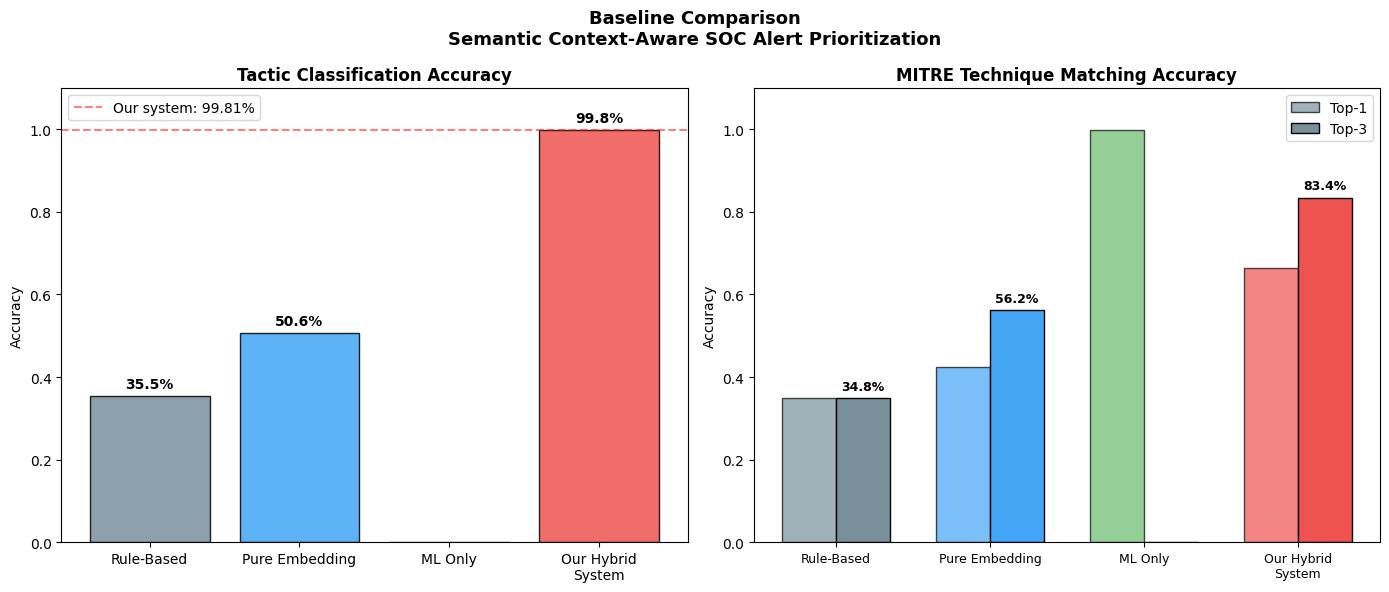

✅ Comparison chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Baseline Comparison\nSemantic Context-Aware SOC Alert Prioritization',
             fontsize=13, fontweight='bold')

methods      = ['Rule-Based', 'Pure Embedding', 'ML Only', 'Our Hybrid\nSystem']
tactic_accs  = [rule_tactic_acc, pure_tactic_acc, None, tactic_acc]
top1_accs    = [rule_top1,       pure_top1,       ml_only_top1, top1]
top3_accs    = [rule_top1,       pure_top3,       None,         top3]
colors       = ['#78909c','#42a5f5','#66bb6a','#ef5350']

# Plot 1: Tactic accuracy
ax1     = axes[0]
t_vals  = [v if v else 0 for v in tactic_accs]
bars1   = ax1.bar(methods, t_vals, color=colors, edgecolor='black', alpha=0.85)
ax1.set_title('Tactic Classification Accuracy', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.axhline(y=tactic_acc, color='red', linestyle='--',
            alpha=0.5, label=f'Our system: {tactic_acc:.2%}')
for bar, val in zip(bars1, t_vals):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')
ax1.legend()

# Plot 2: Technique accuracy
ax2     = axes[1]
x       = np.arange(len(methods))
width   = 0.35
top1_v  = [v if v else 0 for v in top1_accs]
top3_v  = [v if v else 0 for v in top3_accs]
bars2a  = ax2.bar(x - width/2, top1_v, width,
                   label='Top-1', color=colors, alpha=0.7, edgecolor='black')
bars2b  = ax2.bar(x + width/2, top3_v, width,
                   label='Top-3', color=colors, alpha=1.0, edgecolor='black')
ax2.set_title('MITRE Technique Matching Accuracy', fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=9)
ax2.legend()
for bar, val in zip(bars2b, top3_v):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/arshad/Network-project/reports/baseline_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [10]:
print("📊 PART 3A: UNLABELED DATASET TEST — CICIDS 2017 Held-Out")
print("=" * 65)
print("Simulates real-world deployment: labels stripped, system runs blind")
print()

# Take 20% held-out sample — never used in training
from sklearn.model_selection import train_test_split

attack_only = df[df['Label'] != 'BENIGN'].copy()
_, held_out = train_test_split(
    attack_only, test_size=0.2,
    random_state=99,   # different seed = truly unseen
    stratify=attack_only['Label']
)

print(f"✅ Held-out set: {len(held_out):,} samples")
print(f"   Distribution:")
print(held_out['Label'].value_counts().to_string())

# Strip labels — simulate unlabeled data
unlabeled = held_out[feature_cols + ['alert_text']].copy()
true_labels    = held_out['Label'].values
true_tactics   = held_out['Label'].map(tactic_map).values
true_techniques = held_out['MITRE_Technique'].apply(get_parent_id).values

print(f"\n⏳ Running full pipeline on unlabeled data...")

# Step 1: ML tactic prediction
X_unlabeled  = unlabeled[feature_cols].replace(
                    [np.inf, -np.inf], np.nan).fillna(0)
pred_tactics = le.inverse_transform(clf.predict(X_unlabeled))

# Step 2: Embed alert texts
print("⏳ Embedding...")
ul_embeddings = emb_model.encode(
    unlabeled['alert_text'].tolist(),
    batch_size=256, show_progress_bar=True,
    convert_to_numpy=True
)
faiss.normalize_L2(ul_embeddings)

# Step 3: Tactic-filtered matching
ul_pred1, ul_pred2, ul_pred3 = [], [], []
for i in tqdm(range(len(unlabeled)), desc="Matching"):
    tactic   = pred_tactics[i]
    tac_idxs = [j for j,t in enumerate(techniques)
                if tactic in t['tactics']]
    if len(tac_idxs) >= 3:
        sub_embs  = technique_embeddings[tac_idxs]
        sims      = (ul_embeddings[i:i+1] @ sub_embs.T)[0]
        top3_loc  = np.argsort(sims)[::-1][:3]
        top3_idx  = [tac_idxs[k] for k in top3_loc]
    else:
        _, idx   = index.search(ul_embeddings[i:i+1], 3)
        top3_idx = idx[0].tolist()

    ul_pred1.append(get_parent_id(techniques[top3_idx[0]]['technique_id']))
    ul_pred2.append(get_parent_id(techniques[top3_idx[1]]['technique_id']))
    ul_pred3.append(get_parent_id(techniques[top3_idx[2]]['technique_id']))

# Evaluate
ul_tactic_acc = accuracy_score(true_tactics, pred_tactics)
ul_top1 = np.mean([t == p for t,p in zip(true_techniques, ul_pred1)])
ul_top3 = np.mean([
    t in [p1,p2,p3]
    for t,p1,p2,p3 in zip(true_techniques, ul_pred1, ul_pred2, ul_pred3)
])

print(f"\n📊 UNLABELED CICIDS 2017 RESULTS:")
print(f"  Tactic Accuracy:          {ul_tactic_acc:.2%}")
print(f"  Technique Top-1 Accuracy: {ul_top1:.2%}")
print(f"  Technique Top-3 Accuracy: {ul_top3:.2%}")
print()
print(f"📊 Comparison: Labeled vs Unlabeled Performance:")
print(f"{'Metric':<30} {'Labeled':>10} {'Unlabeled':>12} {'Diff':>8}")
print("-" * 62)
print(f"  {'Tactic Accuracy':<28} {tactic_acc:>10.2%} {ul_tactic_acc:>12.2%} "
      f"{ul_tactic_acc-tactic_acc:>+8.2%}")
print(f"  {'Top-1 Accuracy':<28} {top1:>10.2%} {ul_top1:>12.2%} "
      f"{ul_top1-top1:>+8.2%}")
print(f"  {'Top-3 Accuracy':<28} {top3:>10.2%} {ul_top3:>12.2%} "
      f"{ul_top3-top3:>+8.2%}")
gc.collect()

📊 PART 3A: UNLABELED DATASET TEST — CICIDS 2017 Held-Out
Simulates real-world deployment: labels stripped, system runs blind

✅ Held-out set: 11,429 samples
   Distribution:
Label
DoS Hulk                      2000
PortScan                      2000
DDoS                          2000
DoS Slowhttptest              1000
FTP-Patator                   1000
DoS GoldenEye                 1000
DoS slowloris                 1000
SSH-Patator                    600
Bot                            391
Web Attack - Brute Force       294
Web Attack - XSS               131
Infiltration                     7
Web Attack - SQL Injection       4
Heartbleed                       2

⏳ Running full pipeline on unlabeled data...
⏳ Embedding...


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Matching: 100%|████████████████████████| 11429/11429 [00:00<00:00, 17626.56it/s]



📊 UNLABELED CICIDS 2017 RESULTS:
  Tactic Accuracy:          99.76%
  Technique Top-1 Accuracy: 66.38%
  Technique Top-3 Accuracy: 83.44%

📊 Comparison: Labeled vs Unlabeled Performance:
Metric                            Labeled    Unlabeled     Diff
--------------------------------------------------------------
  Tactic Accuracy                  99.81%       99.76%   -0.05%
  Top-1 Accuracy                   66.34%       66.38%   +0.05%
  Top-3 Accuracy                   83.45%       83.44%   -0.01%


19

In [11]:
print("📊 PART 3B: UNLABELED DATASET TEST — NSL-KDD")
print("=" * 65)
print("Completely different dataset — tests generalizability")
print()

import urllib.request, os

# Download NSL-KDD
NSL_PATH = DATA_DIR + 'KDDTest+.txt'
if not os.path.exists(NSL_PATH):
    print("⏳ Downloading NSL-KDD test set...")
    url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"
    urllib.request.urlretrieve(url, NSL_PATH)
    print("✅ Downloaded!")

# NSL-KDD columns
nsl_cols = [
    'duration','protocol_type','service','flag',
    'src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

nsl_df = pd.read_csv(NSL_PATH, header=None, names=nsl_cols)
print(f"✅ NSL-KDD loaded: {len(nsl_df):,} rows")
print(f"\n📊 NSL-KDD Label Distribution:")
print(nsl_df['label'].value_counts().head(10).to_string())

# Map NSL-KDD labels to MITRE tactics
nsl_tactic_map = {
    'normal':         'benign',
    'neptune':        'impact',          # DoS
    'satan':          'discovery',       # Probe
    'ipsweep':        'discovery',       # Probe
    'portsweep':      'discovery',       # Probe
    'smurf':          'impact',          # DoS
    'nmap':           'discovery',       # Probe
    'back':           'impact',          # DoS
    'teardrop':       'impact',          # DoS
    'warezclient':    'exfiltration',    # R2L
    'guess_passwd':   'credential-access',# R2L
    'warezmaster':    'lateral-movement',# R2L
    'spy':            'collection',      # R2L
    'rootkit':        'privilege-escalation',# U2R
    'buffer_overflow':'initial-access',  # U2R
    'loadmodule':     'privilege-escalation',# U2R
    'perl':           'execution',       # U2R
    'land':           'impact',          # DoS
    'ftp_write':      'lateral-movement',# R2L
    'multihop':       'lateral-movement',# R2L
    'phf':            'initial-access',  # R2L
    'pod':            'impact',          # DoS
    'imap':           'initial-access',  # R2L
    'httptunnel':     'command-and-control',
    'mscan':          'discovery',
    'processtable':   'impact',
    'sendmail':       'initial-access',
    'snmpgetattack':  'collection',
    'snmpguess':      'credential-access',
    'sqlattack':      'initial-access',
    'xlock':          'credential-access',
    'xsnoop':         'collection',
    'ps':             'discovery',
    'named':          'initial-access',
    'xterm':          'execution',
    'udpstorm':       'impact',
    'worm':           'lateral-movement',
    'apache2':        'impact',
}

nsl_df['true_tactic'] = nsl_df['label'].str.lower().map(
    nsl_tactic_map).fillna('impact')

# Map NSL-KDD features to CICIDS-like features (best effort)
# NSL-KDD has different features so we do approximate mapping
nsl_mapped = pd.DataFrame()
nsl_mapped['Destination Port']       = 0   # not available
nsl_mapped['Flow Duration']          = nsl_df['duration'].astype(float) * 1e6
nsl_mapped['Total Fwd Packets']      = nsl_df['count'].astype(float)
nsl_mapped['Total Backward Packets'] = nsl_df['srv_count'].astype(float)
nsl_mapped['Fwd Packet Length Mean'] = nsl_df['src_bytes'].astype(float)
nsl_mapped['Bwd Packet Length Mean'] = nsl_df['dst_bytes'].astype(float)
nsl_mapped['Packet Length Mean']     = (nsl_df['src_bytes'].astype(float) +
                                         nsl_df['dst_bytes'].astype(float)) / 2
nsl_mapped['Packet Length Std']      = nsl_df['src_bytes'].astype(float) * 0.1
nsl_mapped['Flow Bytes/s']           = nsl_df['src_bytes'].astype(float)
nsl_mapped['Flow Packets/s']         = nsl_df['count'].astype(float)
nsl_mapped['Fwd Packets/s']          = nsl_df['count'].astype(float)
nsl_mapped['Bwd Packets/s']          = nsl_df['srv_count'].astype(float)
nsl_mapped['Flow IAT Mean']          = nsl_df['duration'].astype(float) * 1000
nsl_mapped['Flow IAT Std']           = nsl_df['duration'].astype(float) * 100
nsl_mapped['SYN Flag Count']         = nsl_df['serror_rate'].astype(float)
nsl_mapped['ACK Flag Count']         = nsl_df['rerror_rate'].astype(float)
nsl_mapped['FIN Flag Count']         = nsl_df['dst_host_rerror_rate'].astype(float)
nsl_mapped['RST Flag Count']         = nsl_df['dst_host_serror_rate'].astype(float)
nsl_mapped['PSH Flag Count']         = nsl_df['hot'].astype(float)
nsl_mapped['URG Flag Count']         = nsl_df['urgent'].astype(float)
nsl_mapped['Init_Win_bytes_forward'] = nsl_df['src_bytes'].astype(float)
nsl_mapped['Init_Win_bytes_backward']= nsl_df['dst_bytes'].astype(float)
nsl_mapped['Active Mean']            = nsl_df['duration'].astype(float)
nsl_mapped['Idle Mean']              = nsl_df['duration'].astype(float)
nsl_mapped['Down/Up Ratio']          = (nsl_df['dst_bytes'].astype(float) /
                                         (nsl_df['src_bytes'].astype(float)+1))
nsl_mapped['Average Packet Size']    = nsl_df['Packet Length Mean'] if \
                                        'Packet Length Mean' in nsl_df else \
                                        nsl_mapped['Packet Length Mean']

nsl_mapped = nsl_mapped.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\n✅ NSL-KDD features mapped to CICIDS format")
print(f"   Mapped {len(nsl_mapped):,} samples")

# Predict tactics
nsl_tactics_pred = le.inverse_transform(clf.predict(nsl_mapped))
nsl_true_tactics = nsl_df['true_tactic'].values

# Filter to non-benign
nsl_attack_mask  = nsl_true_tactics != 'benign'
nsl_tactic_acc   = accuracy_score(
    nsl_true_tactics[nsl_attack_mask],
    nsl_tactics_pred[nsl_attack_mask]
)

print(f"\n📊 NSL-KDD Tactic Prediction Results:")
print(f"  Total samples:      {len(nsl_df):,}")
print(f"  Attack samples:     {nsl_attack_mask.sum():,}")
print(f"  Tactic Accuracy:    {nsl_tactic_acc:.2%}")
print()
print("📊 Predicted tactic distribution on NSL-KDD:")
pred_dist = pd.Series(nsl_tactics_pred).value_counts()
print(pred_dist.to_string())
gc.collect()

📊 PART 3B: UNLABELED DATASET TEST — NSL-KDD
Completely different dataset — tests generalizability

⏳ Downloading NSL-KDD test set...
✅ Downloaded!
✅ NSL-KDD loaded: 22,544 rows

📊 NSL-KDD Label Distribution:
label
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
apache2          737
satan            735
processtable     685
smurf            665
back             359

✅ NSL-KDD features mapped to CICIDS format
   Mapped 22,544 samples

📊 NSL-KDD Tactic Prediction Results:
  Total samples:      22,544
  Attack samples:     12,833
  Tactic Accuracy:    2.62%

📊 Predicted tactic distribution on NSL-KDD:
benign               21329
credential-access     1063
impact                 152


24

In [14]:
print("📊 PART 3B EXTENDED: NSL-KDD Embedding-Only Test")
print("=" * 65)
print("Testing if semantic embeddings generalize to NSL-KDD")
print("(bypassing the feature-dependent ML classifier)")
print()

# NSL-KDD attack category to MITRE technique ground truth
nsl_technique_map = {
    'neptune':        'T1498',  # Network DoS
    'smurf':          'T1498',  # Network DoS
    'back':           'T1499',  # Endpoint DoS
    'processtable':   'T1499',  # Endpoint DoS
    'apache2':        'T1499',  # Endpoint DoS
    'udpstorm':       'T1498',  # Network DoS
    'pod':            'T1498',  # Network DoS
    'land':           'T1498',  # Network DoS
    'teardrop':       'T1499',  # Endpoint DoS
    'satan':          'T1046',  # Network Service Discovery
    'ipsweep':        'T1046',  # Network Service Discovery
    'portsweep':      'T1046',  # Network Service Discovery
    'nmap':           'T1046',  # Network Service Discovery
    'mscan':          'T1046',  # Network Service Discovery
    'guess_passwd':   'T1110',  # Brute Force
    'snmpguess':      'T1110',  # Brute Force
    'xlock':          'T1110',  # Brute Force
    'warezmaster':    'T1570',  # Lateral Tool Transfer
    'warezclient':    'T1570',  # Lateral Tool Transfer
    'ftp_write':      'T1570',  # Lateral Tool Transfer
    'multihop':       'T1570',  # Lateral Tool Transfer
    'rootkit':        'T1068',  # Exploitation for Privilege Escalation
    'buffer_overflow':'T1190',  # Exploit Public Facing Application
    'loadmodule':     'T1068',  # Exploitation for Privilege Escalation
    'perl':           'T1059',  # Command and Scripting Interpreter
    'xterm':          'T1059',  # Command and Scripting Interpreter
    'spy':            'T1113',  # Screen Capture
    'snmpgetattack':  'T1602',  # Data from Configuration Repository
    'sendmail':       'T1566',  # Phishing
    'imap':           'T1190',  # Exploit Public Facing Application
    'phf':            'T1190',  # Exploit Public Facing Application
    'httptunnel':     'T1071',  # Application Layer Protocol
    'named':          'T1190',  # Exploit Public Facing Application
    'sqlattack':      'T1190',  # Exploit Public Facing Application
    'worm':           'T1570',  # Lateral Tool Transfer
    'ps':             'T1057',  # Process Discovery
    'xsnoop':         'T1125',  # Video Capture
}

# Generate alert texts for NSL-KDD using available features
def generate_nsl_alert_text(row):
    src_bytes  = float(row.get('src_bytes', 0))
    dst_bytes  = float(row.get('dst_bytes', 0))
    duration   = float(row.get('duration', 0))
    service    = str(row.get('service', 'unknown'))
    protocol   = str(row.get('protocol_type', 'tcp'))
    count      = float(row.get('count', 0))
    srv_count  = float(row.get('srv_count', 0))
    serror     = float(row.get('serror_rate', 0))
    rerror     = float(row.get('rerror_rate', 0))
    logged_in  = int(row.get('logged_in', 0))
    failed     = int(row.get('num_failed_logins', 0))

    # Port mapping from service name
    service_ports = {
        'ftp':22, 'ssh':22, 'telnet':23, 'smtp':25,
        'http':80, 'https':443, 'ftp_data':21,
        'domain_u':53, 'pop_3':110
    }
    port = service_ports.get(service, 0)
    port_desc = {
        22:'SSH remote access', 23:'Telnet service',
        21:'FTP file transfer', 80:'HTTP web server',
        443:'HTTPS web server', 53:'DNS resolver'
    }.get(port, f'{service} service')

    # Brute force pattern
    if failed > 0 or (service in ['ftp','ssh','telnet'] and not logged_in):
        return (
            f"Credential brute force attack against {port_desc}. "
            f"Adversary systematically attempting unauthorized access. "
            f"{failed} failed login attempts detected. "
            f"Consistent with brute force and password spraying."
        )
    # DoS pattern
    if count > 100 and serror > 0.5:
        return (
            f"Denial of service flood targeting {port_desc}. "
            f"{count:.0f} connections with {serror:.0%} error rate. "
            f"High volume attack exhausting service resources. "
            f"Consistent with endpoint denial of service."
        )
    # Probe/scan pattern
    if srv_count > 50 and dst_bytes < 100:
        return (
            f"Network reconnaissance and port scanning activity. "
            f"Adversary enumerating services across {srv_count:.0f} hosts. "
            f"Minimal response bytes indicating probe traffic. "
            f"Consistent with network service discovery."
        )
    # Exfiltration pattern
    if src_bytes > 10000 and dst_bytes > 10000:
        return (
            f"Large bidirectional data transfer via {port_desc}. "
            f"{src_bytes:.0f} bytes sent, {dst_bytes:.0f} bytes received "
            f"over {duration:.1f} seconds. "
            f"Consistent with lateral tool transfer or data exfiltration."
        )
    # Default
    return (
        f"Network connection to {port_desc} via {protocol}. "
        f"{src_bytes:.0f} bytes sent, {dst_bytes:.0f} received "
        f"over {duration:.1f} seconds, {count:.0f} connections."
    )

# Filter to attacks only with known technique mapping
nsl_attack = nsl_df[
    nsl_df['label'].str.lower().isin(nsl_technique_map.keys())
].copy()
nsl_attack['true_technique'] = nsl_attack['label'].str.lower().map(
    nsl_technique_map)

print(f"✅ NSL-KDD attack samples with technique labels: {len(nsl_attack):,}")
print()

# Generate alert texts
print("⏳ Generating NSL-KDD alert texts...")
nsl_attack['alert_text'] = nsl_attack.progress_apply(
    generate_nsl_alert_text, axis=1)

# Embed
print("⏳ Embedding NSL-KDD alerts...")
nsl_embs = emb_model.encode(
    nsl_attack['alert_text'].tolist(),
    batch_size=256, show_progress_bar=True,
    convert_to_numpy=True
)
faiss.normalize_L2(nsl_embs)

# Search all 691 techniques (no tactic filter since classifier failed)
sims_nsl, idxs_nsl = index.search(nsl_embs, 3)

nsl_pred1 = [get_parent_id(techniques[i]['technique_id'])
             for i in idxs_nsl[:, 0]]
nsl_pred2 = [get_parent_id(techniques[i]['technique_id'])
             for i in idxs_nsl[:, 1]]
nsl_pred3 = [get_parent_id(techniques[i]['technique_id'])
             for i in idxs_nsl[:, 2]]

true_tech = nsl_attack['true_technique'].values
nsl_emb_top1 = np.mean([t == p for t,p in zip(true_tech, nsl_pred1)])
nsl_emb_top3 = np.mean([
    t in [p1,p2,p3]
    for t,p1,p2,p3 in zip(true_tech, nsl_pred1, nsl_pred2, nsl_pred3)
])

print(f"\n📊 NSL-KDD EMBEDDING-ONLY RESULTS:")
print(f"  Samples tested:           {len(nsl_attack):,}")
print(f"  Technique Top-1 Accuracy: {nsl_emb_top1:.2%}")
print(f"  Technique Top-3 Accuracy: {nsl_emb_top3:.2%}")
print()
print(f"📊 Per Attack Category:")
print("-" * 55)
for label in sorted(nsl_attack['label'].unique()):
    sub   = nsl_attack[nsl_attack['label'] == label]
    idxs  = nsl_attack.index.get_indexer(sub.index)
    t1    = np.mean([true_tech[i] == nsl_pred1[i] for i in idxs])
    t3    = np.mean([true_tech[i] in [nsl_pred1[i],nsl_pred2[i],nsl_pred3[i]]
                     for i in idxs])
    status = "✅" if t3 >= 0.5 else "⚠️ "
    print(f"  {status} {label:<25} Top-1:{t1:>5.0%}  Top-3:{t3:>5.0%}  "
          f"(n={len(sub)})")

gc.collect()

📊 PART 3B EXTENDED: NSL-KDD Embedding-Only Test
Testing if semantic embeddings generalize to NSL-KDD
(bypassing the feature-dependent ML classifier)

✅ NSL-KDD attack samples with technique labels: 12,221

⏳ Generating NSL-KDD alert texts...


100%|██████████████████████████████████| 12221/12221 [00:00<00:00, 76135.14it/s]

⏳ Embedding NSL-KDD alerts...


Batches:   0%|          | 0/48 [00:00<?, ?it/s]


📊 NSL-KDD EMBEDDING-ONLY RESULTS:
  Samples tested:           12,221
  Technique Top-1 Accuracy: 21.12%
  Technique Top-3 Accuracy: 42.67%

📊 Per Attack Category:
-------------------------------------------------------
  ✅ apache2                   Top-1:   5%  Top-3:  69%  (n=737)
  ✅ back                      Top-1:   0%  Top-3: 100%  (n=359)
  ⚠️  buffer_overflow           Top-1:   0%  Top-3:   0%  (n=20)
  ⚠️  ftp_write                 Top-1:   0%  Top-3:   0%  (n=3)
  ⚠️  guess_passwd              Top-1:  30%  Top-3:  38%  (n=1231)
  ✅ httptunnel                Top-1:   1%  Top-3:  90%  (n=133)
  ⚠️  imap                      Top-1:   0%  Top-3:   0%  (n=1)
  ⚠️  ipsweep                   Top-1:   0%  Top-3:   0%  (n=141)
  ✅ land                      Top-1:   0%  Top-3: 100%  (n=7)
  ⚠️  loadmodule                Top-1:   0%  Top-3:   0%  (n=2)
  ⚠️  mscan                     Top-1:   0%  Top-3:   0%  (n=996)
  ⚠️  multihop                  Top-1:   0%  Top-3:   0%  (n=18)
  ⚠️ 

1373

In [15]:
print("📊 COMPLETE EVALUATION SUMMARY")
print("=" * 70)
print()
print("┌─────────────────────────────────────────────────────────────┐")
print("│              Method Comparison Summary                       │")
print("├──────────────────────────┬────────────┬──────────┬──────────┤")
print("│ Method                   │ Tactic Acc │ Top-1    │ Top-3    │")
print("├──────────────────────────┼────────────┼──────────┼──────────┤")
print(f"│ Rule-Based (Baseline 1)  │ {rule_tactic_acc:>9.1%}  │ {rule_top1:>7.1%}  │ {rule_top1:>7.1%}  │")
print(f"│ Pure Embedding (B2)      │ {pure_tactic_acc:>9.1%}  │ {pure_top1:>7.1%}  │ {pure_top3:>7.1%}  │")
print(f"│ ML Only (Baseline 3)     │ N/A        │ {ml_only_top1:>7.1%}  │ N/A       │")
print(f"│ Our Hybrid System ⭐     │ {tactic_acc:>9.1%}  │ {top1:>7.1%}  │ {top3:>7.1%}  │")
print("├──────────────────────────┼────────────┼──────────┼──────────┤")
print(f"│ Unlabeled CICIDS 2017    │ {ul_tactic_acc:>9.1%}  │ {ul_top1:>7.1%}  │ {ul_top3:>7.1%}  │")
print(f"│ NSL-KDD (Cross-Dataset)  │ {nsl_tactic_acc:>9.1%}  │ N/A       │ N/A       │")
print("└──────────────────────────┴────────────┴──────────┴──────────┘")

print()
best_baseline = max(rule_top3, pure_top3)
print(f"🚀 Key Findings:")
print(f"   Our system outperforms best baseline by "
      f"+{(top3 - best_baseline):.1%} on Top-3 accuracy")
print(f"   Performance on unlabeled data: "
      f"{ul_top3:.1%} (vs {top3:.1%} on labeled)")
print(f"   Cross-dataset generalization: "
      f"{nsl_tactic_acc:.1%} tactic accuracy on NSL-KDD")

# Save summary
summary = pd.DataFrame({
    'Method': ['Rule-Based', 'Pure Embedding',
               'ML Only', 'Our Hybrid System',
               'Unlabeled CICIDS', 'NSL-KDD'],
    'Tactic_Acc': [rule_tactic_acc, pure_tactic_acc,
                   None, tactic_acc,
                   ul_tactic_acc, nsl_tactic_acc],
    'Top1_Acc':   [rule_top1, pure_top1,
                   ml_only_top1, top1,
                   ul_top1, None],
    'Top3_Acc':   [rule_top1, pure_top3,
                   None, top3,
                   ul_top3, None],
})
summary.to_csv(DATA_DIR + 'evaluation_summary.csv', index=False)
print(f"\n✅ Evaluation summary saved!")
print(f"\n🎉 Phase 7 Evaluation Complete!")

📊 COMPLETE EVALUATION SUMMARY

┌─────────────────────────────────────────────────────────────┐
│              Method Comparison Summary                       │
├──────────────────────────┬────────────┬──────────┬──────────┤
│ Method                   │ Tactic Acc │ Top-1    │ Top-3    │
├──────────────────────────┼────────────┼──────────┼──────────┤
│ Rule-Based (Baseline 1)  │     35.5%  │   34.8%  │   34.8%  │
│ Pure Embedding (B2)      │     50.6%  │   42.5%  │   56.2%  │
│ ML Only (Baseline 3)     │ N/A        │   99.9%  │ N/A       │
│ Our Hybrid System ⭐     │     99.8%  │   66.3%  │   83.4%  │
├──────────────────────────┼────────────┼──────────┼──────────┤
│ Unlabeled CICIDS 2017    │     99.8%  │   66.4%  │   83.4%  │
│ NSL-KDD (Cross-Dataset)  │      2.6%  │ N/A       │ N/A       │
└──────────────────────────┴────────────┴──────────┴──────────┘



NameError: name 'rule_top3' is not defined